In [55]:
import pandas as pd
import os
import csv
from scipy.special import softmax

In [4]:
datafile = "experiment_1b_v2"
data = []
with open(os.path.join("../../data/", f"{datafile}.csv"), 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        story = ' '.join(row)
        data.append(story)

In [7]:
data[0]

'Alex bought a new electric kettle. A friend asked him, "Was it expensive?" Alex said, "It cost $50."\nQ: Please rate how likely it is that the electric kettle cost $50 on a continuous scale ranging from "impossible" to "extremely likely".'

In [6]:
data_df = pd.DataFrame(data, columns=['story'])
data_df

,story
0,Alex bought a new electric kettle. A friend as...
1,Alex bought a new electric kettle. A friend as...
2,Alex bought a new electric kettle. A friend as...
3,Alex bought a new electric kettle. A friend as...
4,Alex bought a new electric kettle. A friend as...
...,...
295,"Gary bought a new watch. A friend asked him, ""..."
296,"Gary bought a new watch. A friend asked him, ""..."
297,"Gary bought a new watch. A friend asked him, ""..."
298,"Gary bought a new watch. A friend asked him, ""..."


In [10]:
data_df["context"] = data_df["story"].apply(lambda x: x.split(".")[0])
data_df["utterance"] = data_df["story"].apply(lambda x: x.split("It cost ")[1].split("\nQ")[0].replace('."', ''))
data_df["question"] = data_df["story"].apply(lambda x: x.split("\nQ: ")[1])
data_df["state"] = data_df["question"].apply(lambda x: x.split("cost ")[1].split(" on a continuous")[0])

In [15]:
data_df["sentence"] = "It cost "
data_df["prompt"] = data_df["question"]

In [16]:
# data_df[["context", "utterance", "sentence", "prompt", "state"]]

,context,utterance,sentence,prompt,state
0,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,$50
1,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,$48
2,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,$500
3,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,$501
4,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,$1000
...,...,...,...,...,...
295,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,$999
296,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,$5000
297,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,$4998
298,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,$10000


In [18]:
datafile = "experiment_1b_v3"
data_v3 = []
with open(os.path.join("../../data/", f"{datafile}.csv"), 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        story = ' '.join(row)
        data_v3.append(story)

In [20]:
data_v3[0]
data_df_v3 = pd.DataFrame(data_v3, columns=['story'])
data_df_v3["context"] = data_df_v3["story"].apply(lambda x: x.split(".")[0])
data_df_v3["utterance"] = data_df_v3["story"].apply(lambda x: x.split("It cost ")[1].split("\nQ")[0].replace('."', ''))
data_df_v3["question"] = data_df_v3["story"].apply(lambda x: x.split("\nQ: ")[1])
data_df_v3["state"] = data_df_v3["question"].apply(lambda x: x.split("cost ")[1].split(" on a continuous")[0])

In [22]:
data_df["probability_prompt"] = data_df_v3['question']

In [26]:
data_df["likert_prompt"] = data_df["prompt"].apply(lambda x: x.replace(" continuous", ""))

In [27]:
# data_df[["context", "utterance", "sentence", "likert_prompt", "probability_prompt", "state"]].to_csv("../../data/experiment_1b_raw.csv", index=False)

In [28]:
# experiment 1a
datafile = "experiment_1a_v2"
data_1a = []
with open(os.path.join("../../data/", f"{datafile}.csv"), 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        story = ' '.join(row)
        data_1a.append(story)

data_1a[0]

'Alex bought a new electric kettle. A friend asked him, "Was it expensive?" Alex said, "It cost $50."\nQ: How likely is it that Alex thinks the electric kettle was expensive on a continuous scale ranging from "impossible" to "absolutely certain"?'

In [29]:
data_1a_df = pd.DataFrame(data_1a, columns=['story'])
data_1a_df["context"] = data_1a_df["story"].apply(lambda x: x.split(".")[0])
data_1a_df["utterance"] = data_1a_df["story"].apply(lambda x: x.split("It cost ")[1].split("\nQ")[0].replace('."', ''))
data_1a_df["question"] = data_1a_df["story"].apply(lambda x: x.split("\nQ: ")[1])
data_1a_df["likert_prompt"] = data_df["question"].apply(lambda x: x.replace(" continuous", ""))

In [31]:
datafile = "experiment_1a_v3"
data_1a_v3 = []
with open(os.path.join("../../data/", f"{datafile}.csv"), 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        story = ' '.join(row)
        data_1a_v3.append(story)

data_1a_v3_df = pd.DataFrame(data_1a_v3, columns=['story'])

data_1a_v3_df["context"] = data_1a_v3_df["story"].apply(lambda x: x.split(".")[0])
data_1a_v3_df["utterance"] = data_1a_v3_df["story"].apply(lambda x: x.split("It cost ")[1].split("\nQ")[0].replace('."', ''))
data_1a_v3_df["question"] = data_1a_v3_df["story"].apply(lambda x: x.split("\nQ: ")[1])
data_1a_v3_df["probability_prompt"] = data_1a_v3_df["question"].apply(lambda x: x.replace(" continuous", ""))

In [33]:
data_1a_df["probability_prompt"] = data_1a_v3_df["probability_prompt"]

In [41]:
data_1a_df["question"] = data_1a_df["story"].apply(lambda x: x.split(".")[1].split('?"')[0] + '?"')
data_1a_df["sentence"] = data_1a_df["story"].apply(lambda x: x.split('expensive?" ')[1].split('"It cost ')[0])

data_1a_df

,story,context,utterance,question,likert_prompt,probability_prompt,sentence
0,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","Alex said,"
1,Bob bought a new electric kettle. A friend ask...,Bob bought a new electric kettle,$53,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","Bob said,"
2,Calvin bought a new electric kettle. A friend ...,Calvin bought a new electric kettle,$500,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","Calvin said,"
3,David bought a new electric kettle. A friend a...,David bought a new electric kettle,$502,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","David said,"
4,Eric bought a new electric kettle. A friend as...,Eric bought a new electric kettle,$1000,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","Eric said,"
5,Frank bought a new electric kettle. A friend a...,Frank bought a new electric kettle,$1003,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","Frank said,"
6,George bought a new electric kettle. A friend ...,George bought a new electric kettle,$5000,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","George said,"
7,Harry bought a new electric kettle. A friend a...,Harry bought a new electric kettle,$4998,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","Harry said,"
8,Ivan bought a new electric kettle. A friend as...,Ivan bought a new electric kettle,$10000,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","Ivan said,"
9,Jake bought a new electric kettle. A friend as...,Jake bought a new electric kettle,$9999,"A friend asked him, ""Was it expensive?""",Please rate how likely it is that the electric...,"Please rate, on a scale from 0 to 1, the proba...","Jake said,"


In [42]:
# data_1a_df[["context", "sentence", "question", "utterance", "likert_prompt", "probability_prompt"]].to_csv("../../data/experiment_1a_raw.csv", index=False)

In [40]:
data_1a_v3[0]

'Alex bought a new electric kettle. A friend asked him, "Was it expensive?" Alex said, "It cost $50."\nQ: Please rate, on a continuous scale from 0 to 1, the probability that Alex considers the electric kettle to be expensive.'

In [43]:
# combine the results with the annotated df
with open("../../data/results_pt/experiment_1b_v2/gpt-4o-mini_0shot_0.0_50_0_graded_answers.txt", "r") as f:
    gpt_4o_mini_0shot_0 = f.readlines()

In [46]:
gpt_4o_mini_0shot_0_processed = [l.replace('\n', '') for l in gpt_4o_mini_0shot_0]
data_df['results_0shot'] = gpt_4o_mini_0shot_0_processed

In [48]:
# combine the results with the annotated df
with open("../../data/results_pt/experiment_1b_v2/gpt-4o-mini_1shot_cot_goal_0.0_50_0_graded_answers.txt", "r") as f:
    gpt_4o_mini_goals = f.readlines()
    gpt_4o_mini_goals = [l.replace('\n', '') for l in gpt_4o_mini_goals]

In [50]:
data_df['results_1shot_goals'] = gpt_4o_mini_goals

In [52]:
# combine the results with the annotated df
with open("../../data/results_pt/experiment_1b_v2/gpt-4o-mini_2shot_example_0.0_50_0_graded_answers.txt", "r") as f:
    gpt_4o_mini_example = f.readlines()
    gpt_4o_mini_example = [l.replace('\n', '') for l in gpt_4o_mini_example]

data_df["results_2shot_example"] = gpt_4o_mini_example

In [53]:
# data_df.to_csv("../../data/results_pt/experiment_1b_v2/gpt-4o-mini_1b_annotated.csv", index=False)

In [138]:
data_df["results_0shot"] = data_df["results_0shot"].apply(lambda x: int(x) - 1)
data_df["results_1shot_goals"] = data_df["results_1shot_goals"].apply(lambda x: int(x) - 1)
data_df["results_2shot_example"] = data_df["results_2shot_example"].apply(lambda x: int(x) - 1)

In [139]:
# nomalization of state probabilities, by utterance:
results_0shot_probs = data_df.groupby(['context', 'utterance']).apply(lambda x: softmax(x['results_0shot'])).reset_index()
results_0shot_probs_long = results_0shot_probs.explode(0)
results_0shot_probs_long.columns = ['context', 'utterance', 'results_0shot_probs']
results_0shot_probs_long

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_74590/4235486153.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_0shot_probs = data_df.groupby(['context', 'utterance']).apply(lambda x: softmax(x['results_0shot'])).reset_index()


,context,utterance,results_0shot_probs
0,Albert bought a new watch,$501,0.008533
0,Albert bought a new watch,$501,0.008533
0,Albert bought a new watch,$501,0.465869
0,Albert bought a new watch,$501,0.465869
0,Albert bought a new watch,$501,0.008533
...,...,...,...
29,Zach bought a new watch,$500,0.015724
29,Zach bought a new watch,$500,0.015724
29,Zach bought a new watch,$500,0.015724
29,Zach bought a new watch,$500,0.015724


In [140]:
results_1shot_probs = data_df.groupby(['context', 'utterance']).apply(lambda x: softmax(x['results_1shot_goals'])).reset_index()
results_1shot_probs_long = results_1shot_probs.explode(0)
results_1shot_probs_long.columns = ['context', 'utterance', 'results_1shot_probs']

results_2shot_probs = data_df.groupby(['context', 'utterance']).apply(lambda x: softmax(x['results_2shot_example'])).reset_index()
results_2shot_probs_long = results_2shot_probs.explode(0)
results_2shot_probs_long.columns = ['context', 'utterance', 'results_2shot_probs']

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_74590/607513847.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_1shot_probs = data_df.groupby(['context', 'utterance']).apply(lambda x: softmax(x['results_1shot_goals'])).reset_index()
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_74590/607513847.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_2shot_probs = data_

In [141]:
states_list = data_df["state"].tolist()

results_1shot_probs_long["state"] = states_list
results_0shot_probs_long["state"] = states_list
results_2shot_probs_long["state"] = states_list

results_1shot_probs_long

,context,utterance,results_1shot_probs,state
0,Albert bought a new watch,$501,0.029781,$50
0,Albert bought a new watch,$501,0.029781,$48
0,Albert bought a new watch,$501,0.220055,$500
0,Albert bought a new watch,$501,0.598171,$501
0,Albert bought a new watch,$501,0.029781,$1000
...,...,...,...,...
29,Zach bought a new watch,$500,0.034593,$999
29,Zach bought a new watch,$500,0.034593,$5000
29,Zach bought a new watch,$500,0.012726,$4998
29,Zach bought a new watch,$500,0.012726,$10000


In [142]:
data_df_combined = data_df.join(results_0shot_probs_long.set_index(["context", "utterance", "state"]), on=["context", "utterance", "state"])
data_df_combined = data_df_combined.join(results_1shot_probs_long.set_index(["context", "utterance", "state"]), on=["context", "utterance", "state"])
data_df_combined = data_df_combined.join(results_2shot_probs_long.set_index(["context", "utterance", "state"]), on=["context", "utterance", "state"])


In [143]:
data_df_combined

,story,context,utterance,question,state,sentence,prompt,probability_prompt,likert_prompt,results_0shot,results_1shot_goals,results_2shot_example,results_0shot_probs,results_1shot_probs,results_2shot_probs
0,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$50,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,4,4,4,0.835902,0.660326,0.660326
1,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$48,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,1,3,3,0.041617,0.24292,0.24292
2,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$500,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0,0,0,0.01531,0.012094,0.012094
3,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$501,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0,0,0,0.01531,0.012094,0.012094
4,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$1000,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0,0,0,0.01531,0.012094,0.012094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$999,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0,0,0,0.012094,0.011014,0.011612
296,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$5000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0,2,1,0.012094,0.081385,0.031564
297,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$4998,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0,1,1,0.012094,0.02994,0.031564
298,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$10000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,3,3,3,0.24292,0.221228,0.233227


In [144]:
# plot the results in a 10 x 3 facet plot, by utterance as column, by object as line
# plotting probabilities on the y-axis as bars, the states on the x-axis

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data_df_combined["results_0shot_probs"] = data_df_combined["results_0shot_probs"].apply(lambda x: round(x, 2))
data_df_combined["results_1shot_probs"] = data_df_combined["results_1shot_probs"].apply(lambda x: round(x, 2))
data_df_combined["results_2shot_probs"] = data_df_combined["results_2shot_probs"].apply(lambda x: round(x, 2))
data_df_combined["object"] = data_df_combined["context"].apply(lambda x: x.split(" ")[-1])


In [145]:
data_df_combined_long = data_df_combined.melt(id_vars=["context", "utterance", "sentence", "prompt", "likert_prompt", "probability_prompt", "state", "results_0shot", "results_1shot_goals", "results_2shot_example", "object"], value_vars=["results_0shot_probs", "results_1shot_probs", "results_2shot_probs"], var_name="shot", value_name="probability")

In [146]:
data_df_combined_long

,context,utterance,sentence,prompt,likert_prompt,probability_prompt,state,results_0shot,results_1shot_goals,results_2shot_example,object,shot,probability
0,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$50,4,4,4,kettle,results_0shot_probs,0.84
1,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$48,1,3,3,kettle,results_0shot_probs,0.04
2,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$500,0,0,0,kettle,results_0shot_probs,0.02
3,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$501,0,0,0,kettle,results_0shot_probs,0.02
4,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$1000,0,0,0,kettle,results_0shot_probs,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",$999,0,0,0,watch,results_2shot_probs,0.01
896,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",$5000,0,2,1,watch,results_2shot_probs,0.03
897,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",$4998,0,1,1,watch,results_2shot_probs,0.03
898,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",$10000,3,3,3,watch,results_2shot_probs,0.23


/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is depr

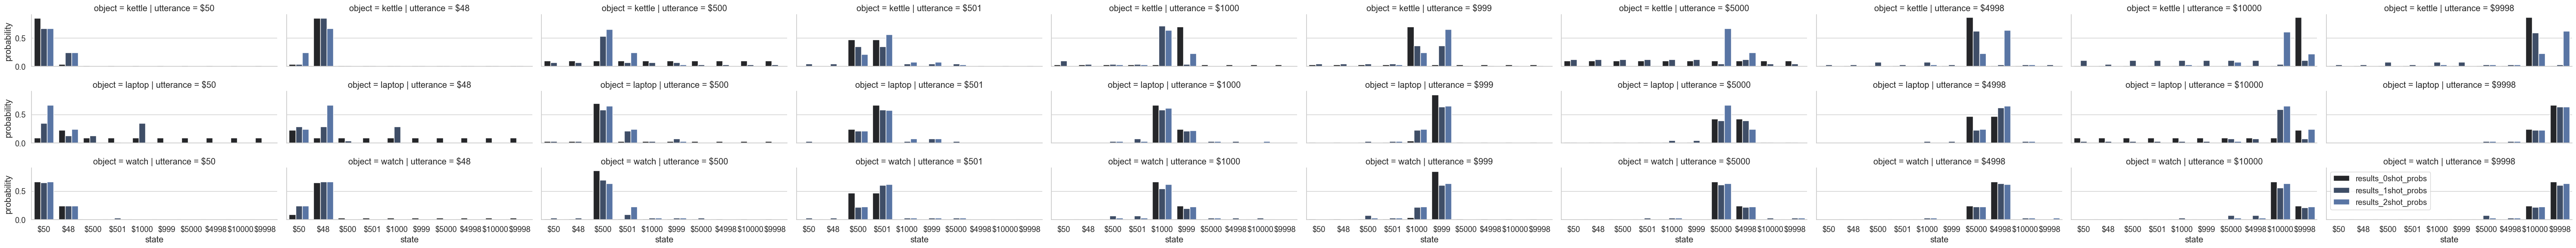

In [147]:
# plot 
p = sns.FacetGrid(data_df_combined_long, col="utterance", row="object", height=2, aspect=3)
p.map_dataframe(sns.barplot, "state", "probability", hue="shot")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
plt.legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()


In [90]:
# categorize the predictions

def categorize_predictions(row):
    state = int(row["state"].replace("$", ""))
    utterance = int(row["utterance"].replace("$", ""))
    if state == utterance:
        interpretation = "exact"
    elif abs(state - utterance) < 4:
        interpretation = "fuzzy"
    elif utterance > state:
        interpretation = "hyperbolic"
    else:
        interpretation = "other"

    return interpretation

In [148]:
# TODO: add human data to the plot
data_df_combined["interpretation"] = data_df_combined.apply(categorize_predictions, axis=1)

In [149]:
data_df_combined_int_long = data_df_combined.melt(id_vars=["context", "utterance", "sentence", "prompt", "interpretation", "likert_prompt", "probability_prompt", "state", "results_0shot", "results_1shot_goals", "results_2shot_example", "object"], value_vars=["results_0shot_probs", "results_1shot_probs", "results_2shot_probs"], var_name="shot", value_name="probability")

In [150]:
data_df_combined_int_long

,context,utterance,sentence,prompt,interpretation,likert_prompt,probability_prompt,state,results_0shot,results_1shot_goals,results_2shot_example,object,shot,probability
0,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,exact,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$50,4,4,4,kettle,results_0shot_probs,0.84
1,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,fuzzy,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$48,1,3,3,kettle,results_0shot_probs,0.04
2,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,other,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$500,0,0,0,kettle,results_0shot_probs,0.02
3,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,other,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$501,0,0,0,kettle,results_0shot_probs,0.02
4,Alex bought a new electric kettle,$50,It cost,Please rate how likely it is that the electric...,other,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",$1000,0,0,0,kettle,results_0shot_probs,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,hyperbolic,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",$999,0,0,0,watch,results_2shot_probs,0.01
896,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,hyperbolic,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",$5000,0,2,1,watch,results_2shot_probs,0.03
897,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,hyperbolic,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",$4998,0,1,1,watch,results_2shot_probs,0.03
898,Gary bought a new watch,$9998,It cost,Please rate how likely it is that the watch co...,fuzzy,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",$10000,3,3,3,watch,results_2shot_probs,0.23


/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/understanding_llms/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is depr

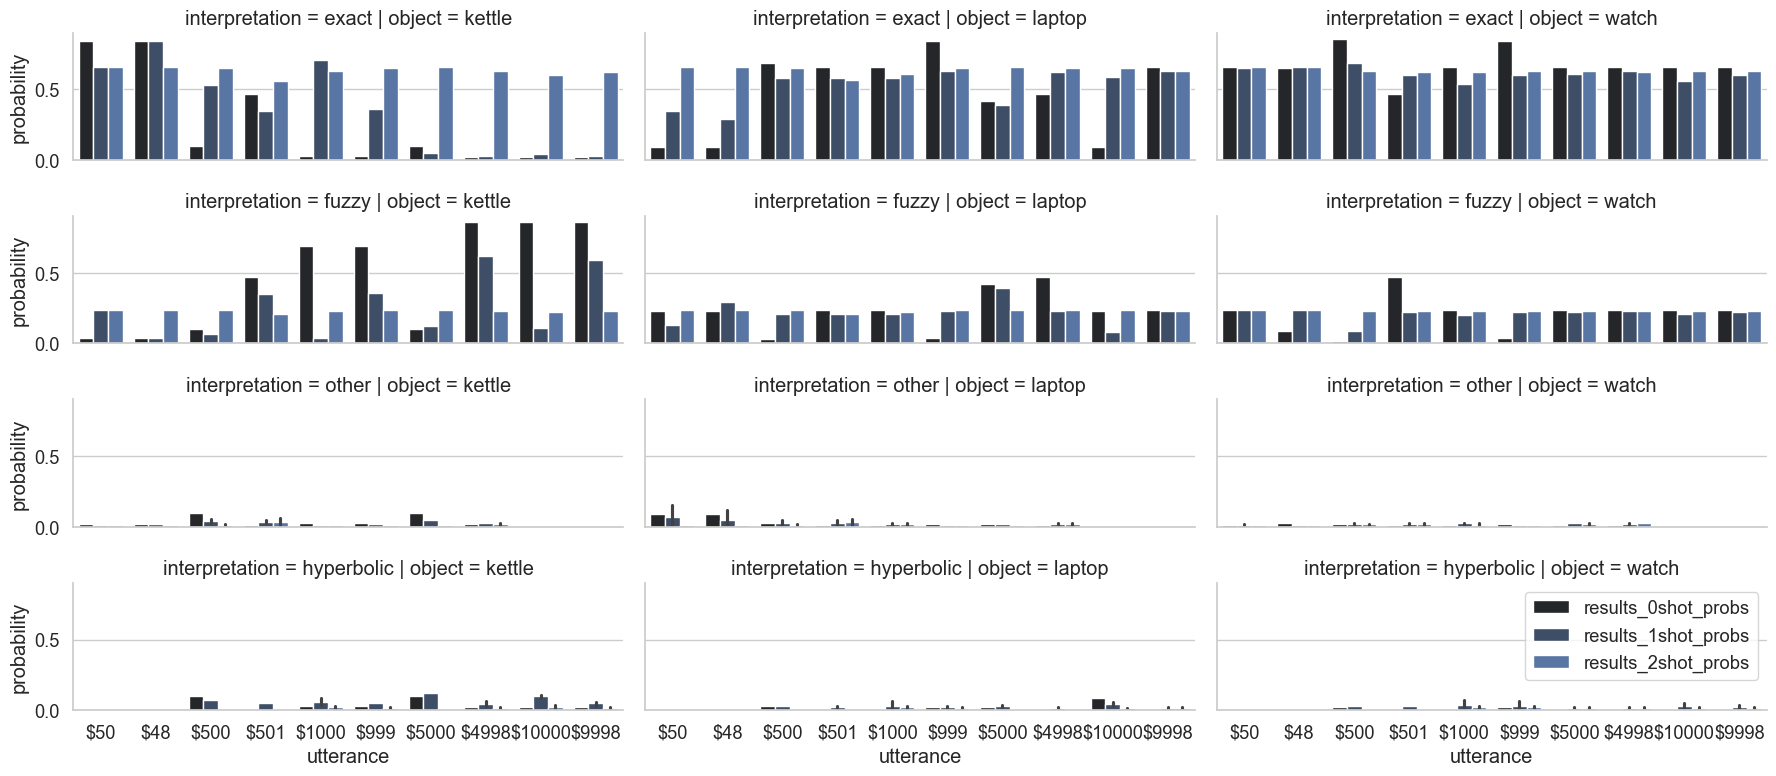

In [151]:
# plot 
p = sns.FacetGrid(data_df_combined_int_long, col="object", row="interpretation", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "probability", hue="shot")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
plt.legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

In [182]:
# reanalyse the data of the gpt-4 runs from the repo
# combine the results with the annotated df
with open("../../data/results/experiment_1b_v3/gpt-4-0613_0shot_0.0_300_0_graded_answers.txt", "r") as f:
    gpt_4_0shot_0 = f.readlines() 

In [185]:
gpt_4_0shot_0 = [l.replace('\n', '') for l in gpt_4_0shot_0]
gpt_4_0shot_0

['1',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '1',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '1',
 '0.1',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0.9',
 '1',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '1',
 '0.01',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0.1',
 '1',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0.01',
 '0',
 '0',
 '1',
 '0.01',
 '0',
 '0',
 '0',
 '0',
 '0.01',
 '0',
 '0',
 '0',
 '0.1',
 '1',
 '0',
 '0',
 '0',
 '0',
 '0.01',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0.01',
 '0.01',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '1',
 '1',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0.0',
 '1',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '1',
 '0.00',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0.1',
 '1',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '1',
 '0.01',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0.0',
 '1',
 '0',
 '0',
 '0',
 '0',

In [186]:
data_df_gpt4 = data_df.copy()
data_df_gpt4["results_0shot"] = gpt_4_0shot_0
data_df_gpt4["object"] = data_df_gpt4["context"].apply(lambda x: x.split(" ")[-1])
data_df_gpt4["results_0shot"] = data_df_gpt4["results_0shot"].apply(lambda x: float(x) ) # int(x) - 1 for v2 data

In [187]:
data_df_gpt4['results_0shot'].unique() 

array([1.  , 0.  , 0.1 , 0.9 , 0.01])

In [191]:
# results_gpt_4_probs = (
#     data_df_gpt4
#     .groupby(['context', 'utterance'])
#     .apply(lambda x: pd.DataFrame({
#         'state': x['state'].tolist(),
#         'softmax_prob': softmax(x['results_0shot'])
#     }))
#     .reset_index(level=[0, 1])  # Reset only the grouping indices
# )

# # Reset the final index to make the DataFrame flat
# results_gpt_4_probs.reset_index(drop=True, inplace=True)
results_gpt_4_probs = data_df_gpt4.copy()
# next line for v2 data
# results_gpt_4_probs["softmax_prob"] = results_gpt_4_probs["results_0shot"] / 4
# next line for v3 data
results_gpt_4_probs["softmax_prob"] = results_gpt_4_probs["results_0shot"]
# View the result
print(results_gpt_4_probs)

                                                 story  \
0    Alex bought a new electric kettle. A friend as...   
1    Alex bought a new electric kettle. A friend as...   
2    Alex bought a new electric kettle. A friend as...   
3    Alex bought a new electric kettle. A friend as...   
4    Alex bought a new electric kettle. A friend as...   
..                                                 ...   
295  Gary bought a new watch. A friend asked him, "...   
296  Gary bought a new watch. A friend asked him, "...   
297  Gary bought a new watch. A friend asked him, "...   
298  Gary bought a new watch. A friend asked him, "...   
299  Gary bought a new watch. A friend asked him, "...   

                               context utterance  \
0    Alex bought a new electric kettle       $50   
1    Alex bought a new electric kettle       $50   
2    Alex bought a new electric kettle       $50   
3    Alex bought a new electric kettle       $50   
4    Alex bought a new electric kettle     

In [192]:
# TODO: add human data to the plot
results_gpt_4_probs["interpretation"] = results_gpt_4_probs.apply(categorize_predictions, axis=1)
results_gpt_4_probs

,story,context,utterance,question,state,sentence,prompt,probability_prompt,likert_prompt,results_0shot,results_1shot_goals,results_2shot_example,object,softmax_prob,interpretation
0,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$50,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,1.0,4,4,kettle,1.0,exact
1,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$48,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0.0,3,3,kettle,0.0,fuzzy
2,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$500,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0.0,0,0,kettle,0.0,other
3,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$501,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0.0,0,0,kettle,0.0,other
4,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$1000,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0.0,0,0,kettle,0.0,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$999,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0.0,0,0,watch,0.0,hyperbolic
296,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$5000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0.0,2,1,watch,0.0,hyperbolic
297,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$4998,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0.0,1,1,watch,0.0,hyperbolic
298,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$10000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0.0,3,3,watch,0.0,fuzzy


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


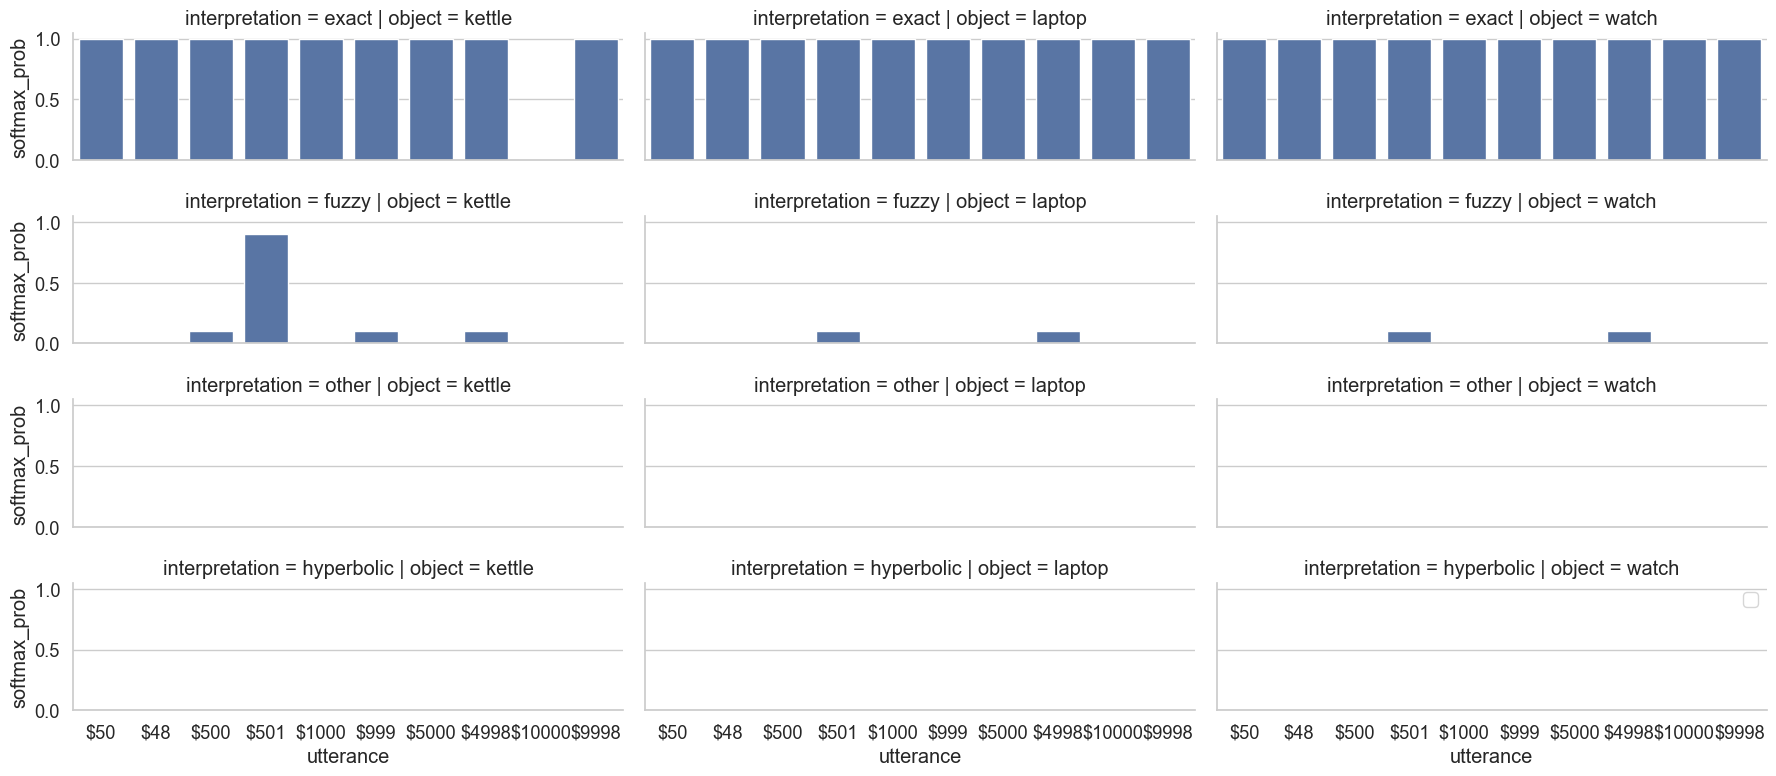

In [193]:
# plot 
results_gpt_4_probs['object'] = results_gpt_4_probs['context'].apply(lambda x: x.split(" ")[-1])
p = sns.FacetGrid(results_gpt_4_probs, col="object", row="interpretation", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "softmax_prob")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
plt.legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

In [158]:
# read human data
human_data = pd.read_csv("../../human_data/experiment1-normalized.csv")
human_data

,workerID,domain,utterance,utteranceType,utteranceExact,utteranceRounded,state,stateType,stateRounded,stateProb,affectProb,order
0,1,electric kettle,1001,sharp,1003,1000,50,round,50,0.014085,0.75,1
1,1,electric kettle,1001,sharp,1003,1000,51,sharp,50,0.014085,0.75,1
2,1,electric kettle,1001,sharp,1003,1000,500,round,500,0.028169,0.75,1
3,1,electric kettle,1001,sharp,1003,1000,501,sharp,500,0.014085,0.75,1
4,1,electric kettle,1001,sharp,1003,1000,1000,round,1000,0.323944,0.75,1
...,...,...,...,...,...,...,...,...,...,...,...,...
17995,120,electric kettle,10001,sharp,9998,10000,1001,sharp,1000,0.036082,1.00,15
17996,120,electric kettle,10001,sharp,9998,10000,5000,round,5000,0.051546,1.00,15
17997,120,electric kettle,10001,sharp,9998,10000,5001,sharp,5000,0.056701,1.00,15
17998,120,electric kettle,10001,sharp,9998,10000,10000,round,10000,0.195876,1.00,15


In [159]:
human_data_summary = human_data.groupby(["domain", "utterance", "state"]).mean("stateProb").reset_index()

In [160]:
human_data_summary['state'].unique()

array([   50,    51,   500,   501,  1000,  1001,  5000,  5001, 10000,
       10001])

In [171]:
results_gpt_4_probs['softmax_prob'].unique()

array([0.01572373, 0.85848645, 0.08533674, 0.23196932, 0.01531008,
       0.04161712, 0.83590221, 0.1       , 0.01209428, 0.24292019,
       0.66032554, 0.01572373, 0.85848645])

In [162]:
def match_humans_to_model(state):
    if state == 51:
        return 48
    elif state == 1001:
        return 999
    elif state == 5001:
        return 4998
    elif state == 10001:
        return 9998
    else:
        return state

In [163]:
human_data_summary["matched_state"] = human_data_summary["state"].apply(match_humans_to_model)  

In [164]:
human_data_summary_subset = human_data_summary[["domain", "utterance", "matched_state", "stateProb"]]
human_data_summary_subset = human_data_summary_subset.rename(columns={"matched_state": "state", "stateProb": "human_prob", "domain": "object"})

In [165]:
human_data_summary_subset["object"] = human_data_summary_subset["object"].apply(lambda x: x.split(" ")[-1])

In [194]:
results_gpt_4_probs["state"] = results_gpt_4_probs["state"].apply(lambda x: int(x.replace("$", "")))
results_gpt_4_probs["utterance"] = results_gpt_4_probs["utterance"].apply(lambda x: int(x.replace("$", "")))

In [195]:
results_gpt_4_probs_wHuman = results_gpt_4_probs.join(human_data_summary_subset.set_index(["state", "utterance", "object"]), on=["state", "utterance", "object"]) #, id_vars=["context", "utterance", "interpretation", "state", "softmax_prob", "object"], value_vars=["results_0shot_probs", "results_1shot_probs", "results_2shot_probs"], var_name="shot", value_name="probability")

results_gpt_4_probs_wHuman

,story,context,utterance,question,state,sentence,prompt,probability_prompt,likert_prompt,results_0shot,results_1shot_goals,results_2shot_example,object,softmax_prob,interpretation,human_prob
0,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,50,Please rate how likely it is that the electric...,50,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,1.0,4,4,kettle,1.0,exact,0.418484
1,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,50,Please rate how likely it is that the electric...,48,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0.0,3,3,kettle,0.0,fuzzy,0.378516
2,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,50,Please rate how likely it is that the electric...,500,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0.0,0,0,kettle,0.0,other,0.055859
3,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,50,Please rate how likely it is that the electric...,501,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0.0,0,0,kettle,0.0,other,0.053655
4,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,50,Please rate how likely it is that the electric...,1000,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,0.0,0,0,kettle,0.0,other,0.023735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,9998,Please rate how likely it is that the watch co...,999,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0.0,0,0,watch,0.0,hyperbolic,NaN
296,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,9998,Please rate how likely it is that the watch co...,5000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0.0,2,1,watch,0.0,hyperbolic,NaN
297,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,9998,Please rate how likely it is that the watch co...,4998,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0.0,1,1,watch,0.0,hyperbolic,NaN
298,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,9998,Please rate how likely it is that the watch co...,10000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,0.0,3,3,watch,0.0,fuzzy,NaN


In [196]:
# check for Nas
results_gpt_4_probs_wHuman.fillna(0, inplace=True)
results_gpt_4_probs_wHuman[results_gpt_4_probs_wHuman["human_prob"].isna()]

,story,context,utterance,question,state,sentence,prompt,probability_prompt,likert_prompt,results_0shot,results_1shot_goals,results_2shot_example,object,softmax_prob,interpretation,human_prob


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_74590/3366115717.py:11: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  scatter_plot = sns.scatterplot(


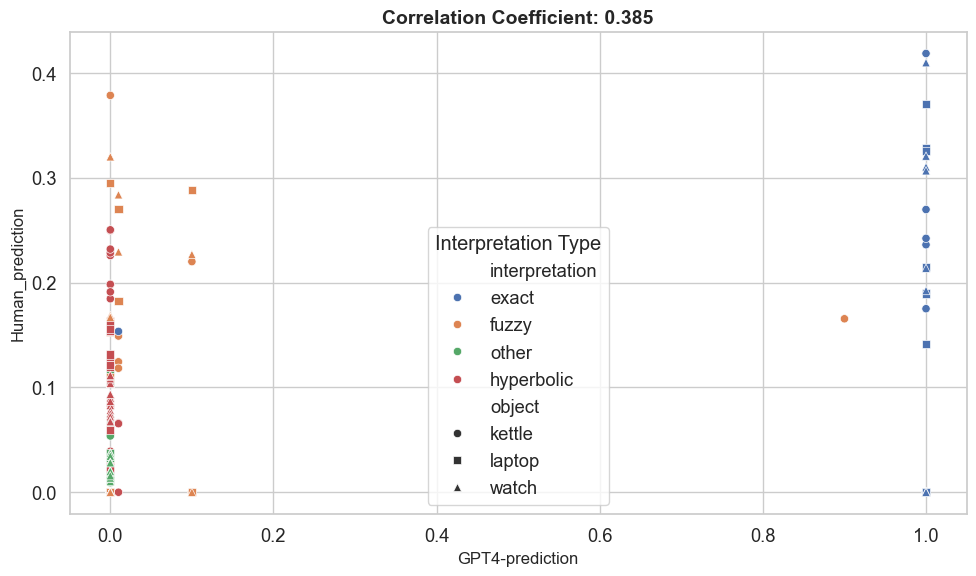

In [197]:
from scipy.stats import pearsonr
# replicate the plot from the write-up (fig 1, but with v2 data?)
# Compute the correlation coefficient
corr_coeff, _ = pearsonr(results_gpt_4_probs_wHuman['softmax_prob'], results_gpt_4_probs_wHuman['human_prob'])

# Set the Seaborn theme
sns.set(style="whitegrid", font_scale=1.2)

# Create the scatter plot with regression line
plt.figure(figsize=(10, 6))
scatter_plot = sns.scatterplot(
    data=results_gpt_4_probs_wHuman,
    x='softmax_prob',
    y='human_prob',
    hue='interpretation',  # Color by Interpretation Type
    style='object',  # Shape by Domain
    # height=6,
    # aspect=1.5,
    markers=['o', 's', '^', 'P'],  # Define marker shapes for each domain
    # scatter_kws={'s': 100},  # Customize scatter point size
    # ci=95  # Confidence interval for regression line
)

# Customize the plot
plt.title(f'Correlation Coefficient: {corr_coeff:.3f}', fontsize=14, weight='bold')
plt.xlabel('GPT4-prediction', fontsize=12)
plt.ylabel('Human_prediction', fontsize=12)
plt.tight_layout()

# Show the legend
plt.legend(title="Interpretation Type", loc="best", frameon=True)

# Display the plot
plt.show()

In [211]:
## analyse "experimental subjects" data
with open("../../data/results_pt/experiment_1b_v2/gpt-4o-mini_0shot_experimentalSubject_0.0_50_0_graded_answers.txt", "r") as f:
    gpt_expt = f.readlines() 

gpt_expt = [l.replace('\n', '') for l in gpt_expt]
gpt_expt

data_df_gpt_expt = data_df.copy()
data_df_gpt_expt["results_0shot"] = gpt_expt
data_df_gpt_expt["object"] = data_df_gpt_expt["context"].apply(lambda x: x.split(" ")[-1])
data_df_gpt_expt["results_0shot"] = data_df_gpt_expt["results_0shot"].apply(lambda x: float(x) ) # int(x) - 1 for v2 data


In [212]:
data_df_gpt_expt_probs = data_df_gpt_expt.copy()
# next line for v2 data
data_df_gpt_expt_probs["softmax_prob"] = (data_df_gpt_expt_probs["results_0shot"] - 1) / 4
# next line for v3 data
# data_df_gpt_expt_probs["softmax_prob"] = data_df_gpt_expt_probs["results_0shot"]
# View the result
print(data_df_gpt_expt_probs)
# TODO: add human data to the plot
data_df_gpt_expt_probs["interpretation"] = data_df_gpt_expt_probs.apply(categorize_predictions, axis=1)
data_df_gpt_expt_probs

                                                 story  \
0    Alex bought a new electric kettle. A friend as...   
1    Alex bought a new electric kettle. A friend as...   
2    Alex bought a new electric kettle. A friend as...   
3    Alex bought a new electric kettle. A friend as...   
4    Alex bought a new electric kettle. A friend as...   
..                                                 ...   
295  Gary bought a new watch. A friend asked him, "...   
296  Gary bought a new watch. A friend asked him, "...   
297  Gary bought a new watch. A friend asked him, "...   
298  Gary bought a new watch. A friend asked him, "...   
299  Gary bought a new watch. A friend asked him, "...   

                               context utterance  \
0    Alex bought a new electric kettle       $50   
1    Alex bought a new electric kettle       $50   
2    Alex bought a new electric kettle       $50   
3    Alex bought a new electric kettle       $50   
4    Alex bought a new electric kettle     

,story,context,utterance,question,state,sentence,prompt,probability_prompt,likert_prompt,results_0shot,results_1shot_goals,results_2shot_example,object,softmax_prob,interpretation
0,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$50,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,5.0,4,4,kettle,1.00,exact
1,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$48,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,4.0,3,3,kettle,0.75,fuzzy
2,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$500,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,1.0,0,0,kettle,0.00,other
3,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$501,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,1.0,0,0,kettle,0.00,other
4,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$1000,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,1.0,0,0,kettle,0.00,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$999,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,1.0,0,0,watch,0.00,hyperbolic
296,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$5000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,1.0,2,1,watch,0.00,hyperbolic
297,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$4998,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,1.0,1,1,watch,0.00,hyperbolic
298,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$10000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,4.0,3,3,watch,0.75,fuzzy


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


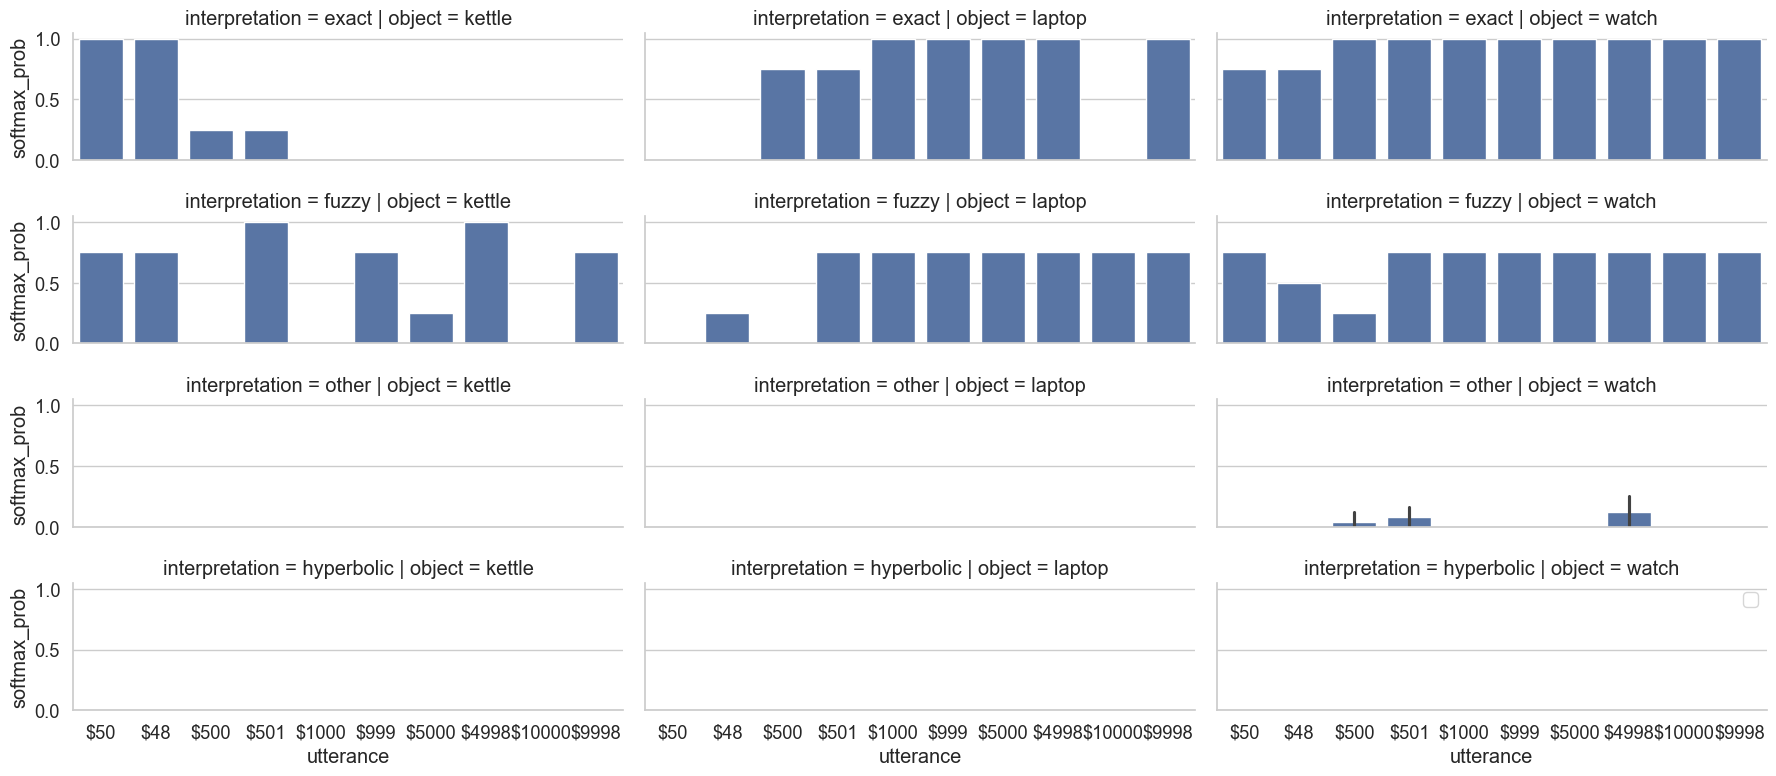

In [213]:
# plot 
data_df_gpt_expt_probs['object'] = data_df_gpt_expt_probs['context'].apply(lambda x: x.split(" ")[-1])
p = sns.FacetGrid(data_df_gpt_expt_probs, col="object", row="interpretation", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "softmax_prob")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
plt.legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

In [214]:
## analyse "experimental subjects" data
with open("../../data/results_pt/experiment_1b_v2/gpt-4o-mini_0shot_wAngryEmoji_0.0_50_0_graded_answers.txt", "r") as f:
    gpt_neg = f.readlines() 

gpt_neg = [l.replace('\n', '') for l in gpt_neg]
gpt_neg

data_df_gpt_neg = data_df.copy()
data_df_gpt_neg["results_0shot"] = gpt_neg
data_df_gpt_neg["object"] = data_df_gpt_neg["context"].apply(lambda x: x.split(" ")[-1])
data_df_gpt_neg["results_0shot"] = data_df_gpt_neg["results_0shot"].apply(lambda x: float(x) ) # int(x) - 1 for v2 data

data_df_gpt_neg_probs = data_df_gpt_neg.copy()
# next line for v2 data
data_df_gpt_neg_probs["softmax_prob"] = (data_df_gpt_neg_probs["results_0shot"] - 1) / 4
# next line for v3 data
# data_df_gpt_expt_probs["softmax_prob"] = data_df_gpt_expt_probs["results_0shot"]
# View the result
# TODO: add human data to the plot
data_df_gpt_neg_probs["interpretation"] = data_df_gpt_neg_probs.apply(categorize_predictions, axis=1)


                                                 story  \
0    Alex bought a new electric kettle. A friend as...   
1    Alex bought a new electric kettle. A friend as...   
2    Alex bought a new electric kettle. A friend as...   
3    Alex bought a new electric kettle. A friend as...   
4    Alex bought a new electric kettle. A friend as...   
..                                                 ...   
295  Gary bought a new watch. A friend asked him, "...   
296  Gary bought a new watch. A friend asked him, "...   
297  Gary bought a new watch. A friend asked him, "...   
298  Gary bought a new watch. A friend asked him, "...   
299  Gary bought a new watch. A friend asked him, "...   

                               context utterance  \
0    Alex bought a new electric kettle       $50   
1    Alex bought a new electric kettle       $50   
2    Alex bought a new electric kettle       $50   
3    Alex bought a new electric kettle       $50   
4    Alex bought a new electric kettle     

,story,context,utterance,question,state,sentence,prompt,probability_prompt,likert_prompt,results_0shot,results_1shot_goals,results_2shot_example,object,softmax_prob,interpretation
0,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$50,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,5.0,4,4,kettle,1.00,exact
1,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$48,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,2.0,3,3,kettle,0.25,fuzzy
2,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$500,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,1.0,0,0,kettle,0.00,other
3,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$501,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,1.0,0,0,kettle,0.00,other
4,Alex bought a new electric kettle. A friend as...,Alex bought a new electric kettle,$50,Please rate how likely it is that the electric...,$1000,It cost,Please rate how likely it is that the electric...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the electric...,1.0,0,0,kettle,0.00,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$999,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,1.0,0,0,watch,0.00,hyperbolic
296,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$5000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,1.0,2,1,watch,0.00,hyperbolic
297,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$4998,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,1.0,1,1,watch,0.00,hyperbolic
298,"Gary bought a new watch. A friend asked him, ""...",Gary bought a new watch,$9998,Please rate how likely it is that the watch co...,$10000,It cost,Please rate how likely it is that the watch co...,"Please rate, on a continuous scale from 0 to 1...",Please rate how likely it is that the watch co...,4.0,3,3,watch,0.75,fuzzy


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


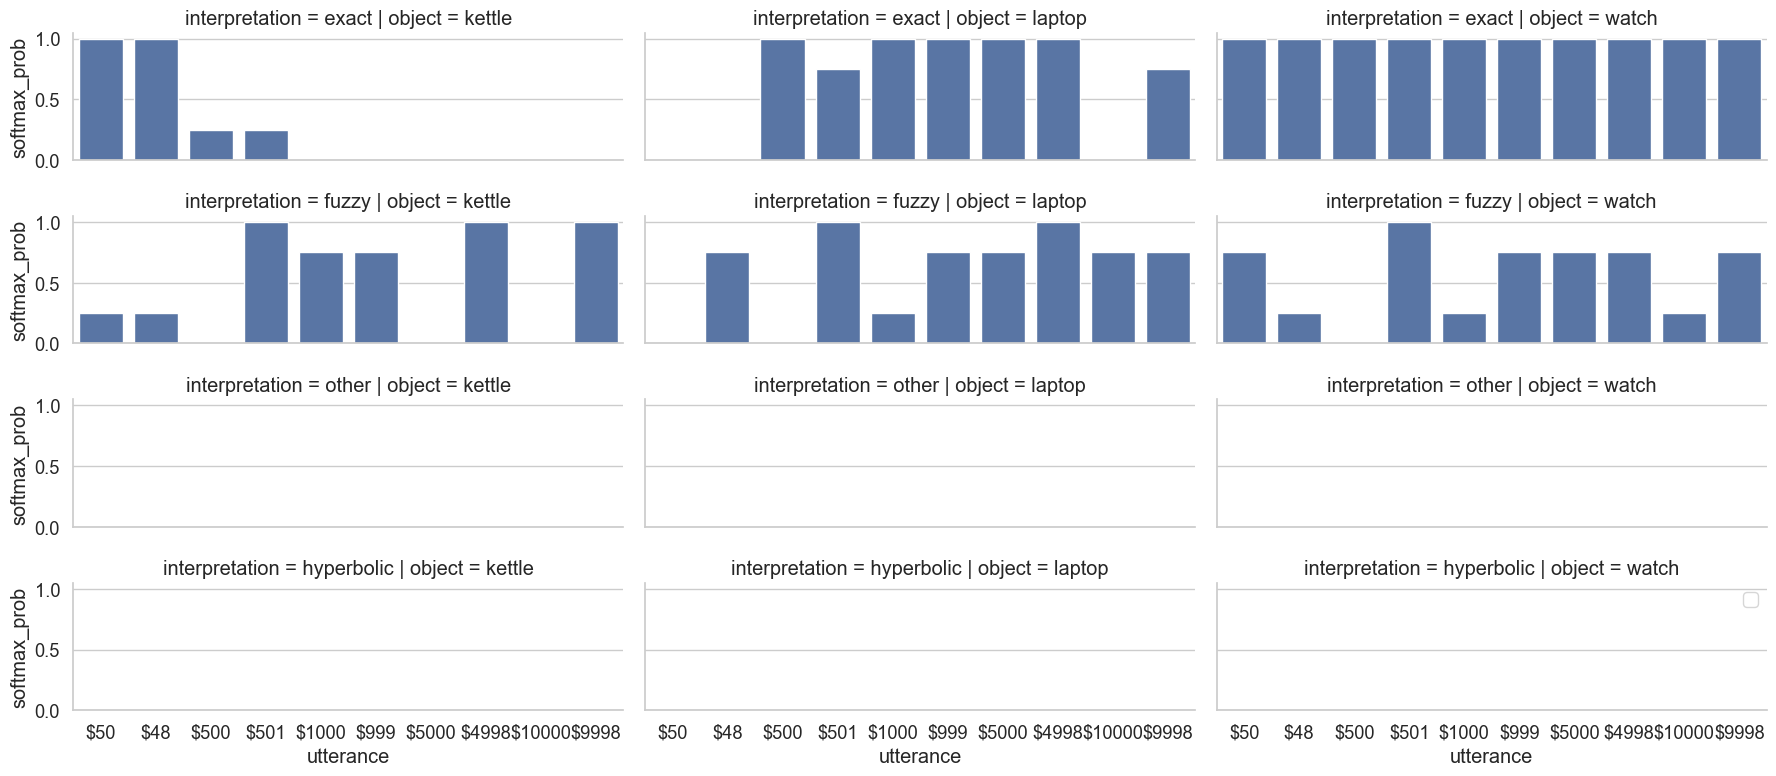

In [215]:
data_df_gpt_neg_probs['object'] = data_df_gpt_neg_probs['context'].apply(lambda x: x.split(" ")[-1])
p = sns.FacetGrid(data_df_gpt_neg_probs, col="object", row="interpretation", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "softmax_prob")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
plt.legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()

In [216]:
## analyse "experimental subjects" data
with open("../../data/results_pt/experiment_1b_v2/gpt-4o-mini_0shot_wHappyEmoji_0.0_50_0_graded_answers.txt", "r") as f:
    gpt_pos = f.readlines() 

gpt_pos = [l.replace('\n', '') for l in gpt_pos]
gpt_pos

data_df_gpt_pos= data_df.copy()
data_df_gpt_pos["results_0shot"] = gpt_pos
data_df_gpt_pos["object"] = data_df_gpt_pos["context"].apply(lambda x: x.split(" ")[-1])
data_df_gpt_pos["results_0shot"] = data_df_gpt_pos["results_0shot"].apply(lambda x: float(x) ) # int(x) - 1 for v2 data

data_df_gpt_pos_probs = data_df_gpt_pos.copy()
# next line for v2 data
data_df_gpt_pos_probs["softmax_prob"] = (data_df_gpt_pos_probs["results_0shot"] - 1) / 4
# next line for v3 data
# data_df_gpt_expt_probs["softmax_prob"] = data_df_gpt_expt_probs["results_0shot"]
# View the result
# TODO: add human data to the plot
data_df_gpt_pos_probs["interpretation"] = data_df_gpt_pos_probs.apply(categorize_predictions, axis=1)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


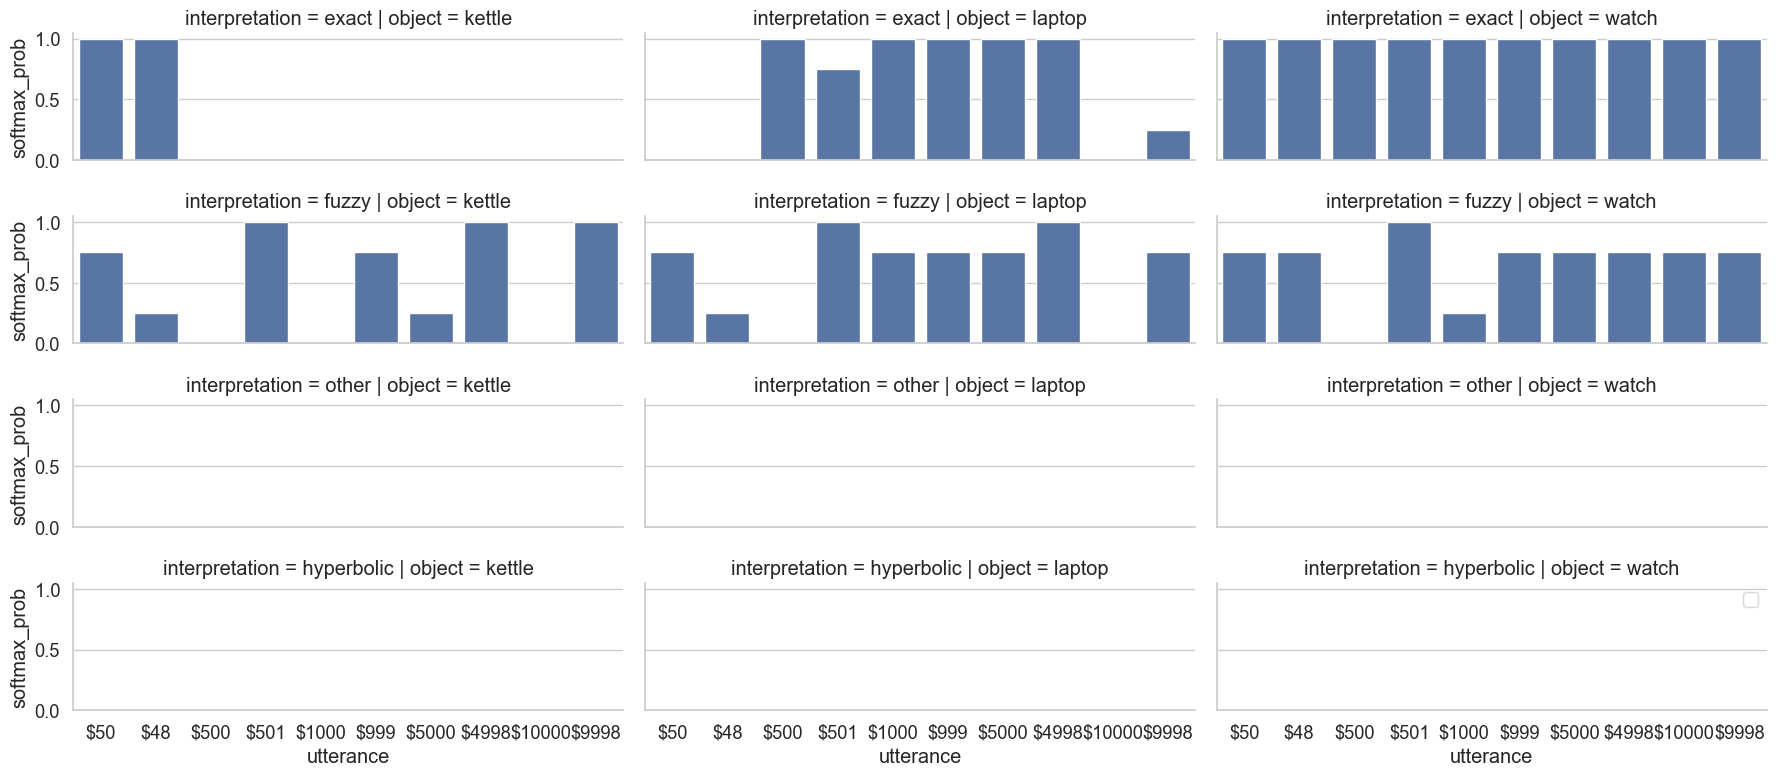

In [217]:
data_df_gpt_pos_probs['object'] = data_df_gpt_pos_probs['context'].apply(lambda x: x.split(" ")[-1])
p = sns.FacetGrid(data_df_gpt_pos_probs, col="object", row="interpretation", height=2, aspect=3)
p.map_dataframe(sns.barplot, "utterance", "softmax_prob")
# p.map(sns.barplot, "state", "results_1shot_probs", color="red", dodge=True)
# p.map(sns.barplot, "state", "results_2shot_probs", color="green", dodge=True)
# p.set_xticklabels(rotation=45)
plt.legend() # title="Prompt", labels=["0-shot", "Goal 1-shot", "Example 2-shot"]
plt.show()